# PCA Dimensionality Analysis

Two parts:

1. **IXPLORE configuration table.** All IXPLORE configurations for which we have 5-seed results (`feature_effect`, `iteration_effect` which also varies the prior $\tau^2$, and `weight_effect` restricted to `schedule=uniform`). Each row reports MAE and ACC for the four evaluation cells, averaged over seeds and the standard sparsity grid `{0.0, 0.3, 0.6, 0.9}`. Best-in-column is bold, runner-up italic.

2. **PCA dimensionality sweep.** Loads the precomputed `pca_sweep` results (run with `python -m src.scripts.run_pca_sweep`) and plots fit/impute accuracy for `pca-linear` and `pca-logistic` as a function of $k$. Horizontal lines mark the best IXPLORE configuration per cell from Part 1.

In [1]:
import sys; sys.path.insert(0, "../..")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.visualization import apply_defaults, subplots
from src.models import ALGORITHM_LABELS
apply_defaults()

DATASET = "smartvote_2023"
RESULTS = Path(f"../../results/{DATASET}")
FIGURES = Path("../../figures")

METRICS = ["fit_mae", "fit_accuracy", "impute_mae", "impute_accuracy"]
CELLS = [
    ("Train Fit",    "train", "fit"),
    ("Train Impute", "train", "impute"),
    ("Test Fit",     "test",  "fit"),
    ("Test Impute",  "test",  "impute"),
]

## Part 1 — IXPLORE configuration table

Rows: every distinct IXPLORE configuration we have results for, labelled by source and the varied hyperparameter(s). Cells: MAE / ACC averaged over 5 seeds and 4 sparsities.

In [2]:
def _agg(df: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    return df.groupby(group_cols, as_index=False)[METRICS].mean()

# ── feature_effect: kernel ∈ {linear, polynomial, rff} ──
fe_train = pd.read_csv(RESULTS / "feature_effect" / "train_metrics.csv")
fe_test  = pd.read_csv(RESULTS / "feature_effect" / "test_metrics.csv")
fe_train_agg = _agg(fe_train, ["model"]).rename(columns={"model": "config"})
fe_test_agg  = _agg(fe_test,  ["model"]).rename(columns={"model": "config"})
fe_train_agg["source"] = "feature_effect"; fe_train_agg["config"] = "kernel=" + fe_train_agg["config"].astype(str)
fe_test_agg["source"]  = "feature_effect"; fe_test_agg["config"]  = "kernel=" + fe_test_agg["config"].astype(str)

# ── iteration_effect: (tau, init, iteration) ──
ie_train = pd.read_csv(RESULTS / "iteration_effect" / "train_metrics.csv")
ie_test  = pd.read_csv(RESULTS / "iteration_effect" / "test_metrics.csv")
def _ie_label(df):
    df = df.copy()
    df["config"] = (
        "τ²=" + df["tau"].astype(str)
        + ", init=" + df["init"].astype(str)
        + ", T=" + df["iteration"].astype(str)
    )
    return df
ie_train_agg = _agg(_ie_label(ie_train), ["config"]); ie_train_agg["source"] = "iteration_effect"
ie_test_agg  = _agg(_ie_label(ie_test),  ["config"]); ie_test_agg["source"]  = "iteration_effect"

# ── weight_effect: schedule=uniform only, both scale_weights ──
we_test_full = pd.read_csv(RESULTS / "weight_effect" / "test_metrics.csv")
we_test = we_test_full[we_test_full["schedule"] == "uniform"].copy()
we_test["config"] = "uniform, scale_weights=" + we_test["scale_weights"].astype(str)
we_test_agg = _agg(we_test, ["config"]); we_test_agg["source"] = "weight_effect"
# weight_effect has no train CSV → train cells are NaN
we_train_agg = we_test_agg[["config", "source"]].copy()
for m in METRICS:
    we_train_agg[m] = np.nan

# ── merge train + test sides ──
def _join(train_agg, test_agg):
    t = train_agg.rename(columns={m: f"train_{m}" for m in METRICS})
    s = test_agg.rename(columns={m: f"test_{m}" for m in METRICS})
    return t.merge(s, on=["config", "source"], how="outer")

table = pd.concat([
    _join(fe_train_agg, fe_test_agg),
    _join(ie_train_agg, ie_test_agg),
    _join(we_train_agg, we_test_agg),
], ignore_index=True)

# Reorder columns to match the report tables
ordered_cols = ["source", "config"]
for split in ["train", "test"]:
    for kind in ["fit", "impute"]:
        ordered_cols += [f"{split}_{kind}_mae", f"{split}_{kind}_accuracy"]
table = table[ordered_cols]
print(f"{len(table)} configurations")

77 configurations


In [3]:
metric_cols = [c for c in table.columns if c not in ("source", "config")]

# Plain table with per-column best (★) and runner-up (·) markers.
def _ranked(col: pd.Series) -> pd.Series:
    valid = col.dropna()
    if valid.empty:
        return pd.Series([""] * len(col), index=col.index)
    ascending = col.name.endswith("_mae")
    sorted_vals = valid.sort_values(ascending=ascending)
    best = sorted_vals.iloc[0]
    runner = sorted_vals.iloc[1] if len(sorted_vals) > 1 else None
    marks = []
    for v in col:
        if pd.isna(v):                              marks.append("")
        elif v == best:                             marks.append("★")
        elif runner is not None and v == runner:    marks.append("·")
        else:                                       marks.append("")
    return pd.Series(marks, index=col.index)

ranks = pd.DataFrame({c: _ranked(table[c]) for c in metric_cols})

# Keep rows that are best OR runner-up in at least one column.
ranked_mask = ranks.isin(["★", "·"]).any(axis=1)

display = table.loc[ranked_mask].copy()
for c in metric_cols:
    display[c] = display[c].round(4).astype(str) + " " + ranks.loc[ranked_mask, c]

display = display.rename(columns={c: c.replace("_accuracy", "_acc") for c in metric_cols})
display

,source,config,train_fit_mae,train_fit_acc,train_impute_mae,train_impute_acc,test_fit_mae,test_fit_acc,test_impute_mae,test_impute_acc
1,feature_effect,kernel=polynomial,0.1532 ·,0.8708 ·,0.1982 ·,0.8079,0.2268,0.7842 ★,0.2592 ★,0.7304 ★
2,feature_effect,kernel=rff,0.1441 ★,0.8786 ★,0.1982 ★,0.8068,0.2321,0.7776,0.2623,0.7267 ·
11,iteration_effect,"τ²=0.05, init=random, T=10",0.1676,0.8525,0.2051,0.7992,0.2253 ★,0.7768,0.2656,0.7171
14,iteration_effect,"τ²=0.05, init=random, T=5",0.1722,0.8475,0.2117,0.7915,0.226 ·,0.7757,0.2672,0.7154
28,iteration_effect,"τ²=0.25, init=pca, T=1",0.1699,0.8529,0.2009,0.808 ·,0.2354,0.7726,0.2625,0.7243
40,iteration_effect,"τ²=0.5, init=pca, T=1",0.1697,0.8531,0.2008,0.808 ★,0.2327,0.774,0.2613,0.7245
67,iteration_effect,"τ²=1000000.0, init=pca, T=20",0.167,0.8548,0.2006,0.8067,0.2285,0.7754,0.26 ·,0.7244
76,weight_effect,"uniform, scale_weights=True",nan,nan,nan,nan,0.2262,0.7781 ·,0.2629,0.7209


In [4]:
# Pick which IXPLORE configuration to use as the reference in Part 2.
# Set SELECTED_SOURCE + SELECTED_CONFIG to a row from the table above.
SELECTED_SOURCE = "iteration_effect" # "feature_effect"
SELECTED_CONFIG = "τ²=0.25, init=pca, T=10" # "kernel=rff"
SELECTED_METRIC = "mae"  # "accuracy" or "mae"

assert SELECTED_METRIC in ("accuracy", "mae"), "SELECTED_METRIC must be 'accuracy' or 'mae'"

selected_row = table[
    (table["source"] == SELECTED_SOURCE) & (table["config"] == SELECTED_CONFIG)
]
assert len(selected_row) == 1, f"No matching row for ({SELECTED_SOURCE}, {SELECTED_CONFIG})"
selected_row = selected_row.iloc[0]

# Pull out per-cell values for the horizontal lines in Part 2.
ixplore_ref = {c: selected_row[c] for c in metric_cols}
print(f"Reference: {SELECTED_SOURCE} / {SELECTED_CONFIG}  |  metric: {SELECTED_METRIC}")
pd.Series(ixplore_ref).round(4)

Reference: iteration_effect / τ²=0.25, init=pca, T=10  |  metric: mae


train_fit_mae            0.1655
train_fit_accuracy       0.8558
train_impute_mae         0.2004
train_impute_accuracy    0.8059
test_fit_mae             0.2293
test_fit_accuracy        0.7754
test_impute_mae          0.2611
test_impute_accuracy     0.7235
dtype: float64

## Part 2 — PCA dimensionality sweep

Loads precomputed sweep results (run `python -m src.scripts.run_pca_sweep` first). Each curve is averaged over 5 seeds × 4 sparsities. Horizontal lines: best IXPLORE accuracy from Part 1, drawn separately for the train and test side.

In [5]:
pca_train = pd.read_csv(RESULTS / "pca_sweep" / "train_metrics.csv")
pca_test  = pd.read_csv(RESULTS / "pca_sweep" / "test_metrics.csv")

pca_train_avg = pca_train.groupby(["model", "k"], as_index=False)[METRICS].mean()
pca_test_avg  = pca_test.groupby(["model", "k"], as_index=False)[METRICS].mean()

# Combine into one frame: rows × (train_*, test_*) columns
pca_avg = pca_train_avg.rename(columns={m: f"train_{m}" for m in METRICS}).merge(
    pca_test_avg.rename(columns={m: f"test_{m}" for m in METRICS}),
    on=["model", "k"], how="outer"
).sort_values(["model", "k"]).reset_index(drop=True)

print("PCA sweep:", pca_avg["model"].unique(), "  k:", pca_avg["k"].min(), "…", pca_avg["k"].max())
pca_avg.head()

PCA sweep: ['pca-linear' 'pca-logistic']   k: 1 … 74


,model,k,train_fit_mae,train_fit_accuracy,train_impute_mae,train_impute_accuracy,test_fit_mae,test_fit_accuracy,test_impute_mae,test_impute_accuracy
0,pca-linear,1,0.272650,0.765456,0.282453,0.748880,0.298887,0.694163,0.305513,0.681593
1,pca-linear,2,0.257950,0.794588,0.274100,0.763933,0.289281,0.716969,0.300793,0.691227
2,pca-linear,3,0.247675,0.812638,0.270093,0.771413,0.283200,0.731181,0.299347,0.694527
3,pca-linear,4,0.240462,0.824400,0.269013,0.772693,0.277875,0.744800,0.298653,0.696313
4,pca-linear,5,0.234469,0.833506,0.269300,0.771493,0.269338,0.759631,0.294787,0.703593


In [6]:
# Smallest k at which each PCA variant first beats the IXPLORE reference,
# per (split × fit/impute) cell, for the currently SELECTED_METRIC.
# Also record the argmin/argmax k per curve as a fallback for "never" cases,
# so the plot below can mark either a crossover line or the curve's own optimum.
metric_label = "MAE" if SELECTED_METRIC == "mae" else "Accuracy"
better_is_smaller = SELECTED_METRIC == "mae"

cells = [
    ("Train Fit",    "train", "fit"),
    ("Train Impute", "train", "impute"),
    ("Test Fit",     "test",  "fit"),
    ("Test Impute",  "test",  "impute"),
]

# crossover_k[variant][(split, kind)] = int k of first crossover, or None if never
# extreme_k[variant][(split, kind)]   = (k, value) at curve's own optimum
# kind ∈ {"fit", "impute"} — independent of the chosen metric
crossover_k: dict[str, dict[tuple[str, str], int | None]] = {}
extreme_k:   dict[str, dict[tuple[str, str], tuple[int, float]]] = {}

rows = {}
for variant in ("pca-linear", "pca-logistic"):
    sub = pca_avg[pca_avg["model"] == variant].sort_values("k")
    row = {}
    crossover_k[variant] = {}
    extreme_k[variant]   = {}
    for label, split, kind in cells:
        col = f"{split}_{kind}_{SELECTED_METRIC}"
        if sub[col].notna().any():
            idx = sub[col].idxmin() if better_is_smaller else sub[col].idxmax()
            extreme_k[variant][(split, kind)] = (int(sub.loc[idx, "k"]), float(sub.loc[idx, col]))
        ref = ixplore_ref.get(col)
        if ref is None or pd.isna(ref):
            row[label] = "--"
            crossover_k[variant][(split, kind)] = None
            continue
        if better_is_smaller:
            beats = sub[sub[col] < ref]
        else:
            beats = sub[sub[col] > ref]
        if beats.empty:
            row[label] = "never"
            crossover_k[variant][(split, kind)] = None
        else:
            k_first = int(beats["k"].min())
            row[label] = k_first
            crossover_k[variant][(split, kind)] = k_first
    rows[ALGORITHM_LABELS[variant]] = row

crossover = pd.DataFrame(rows).T
crossover.index.name = "PCA variant"
crossover.columns = [f"{c} ({metric_label})" for c in crossover.columns]
crossover

,Train Fit (MAE),Train Impute (MAE),Test Fit (MAE),Test Impute (MAE)
PCA variant,,,,
Linear PCA,21,never,15,never
Logistic PCA,3,never,9,never


Saved: ../../figures/pca_dimensionality_mae_smartvote_2023.pdf


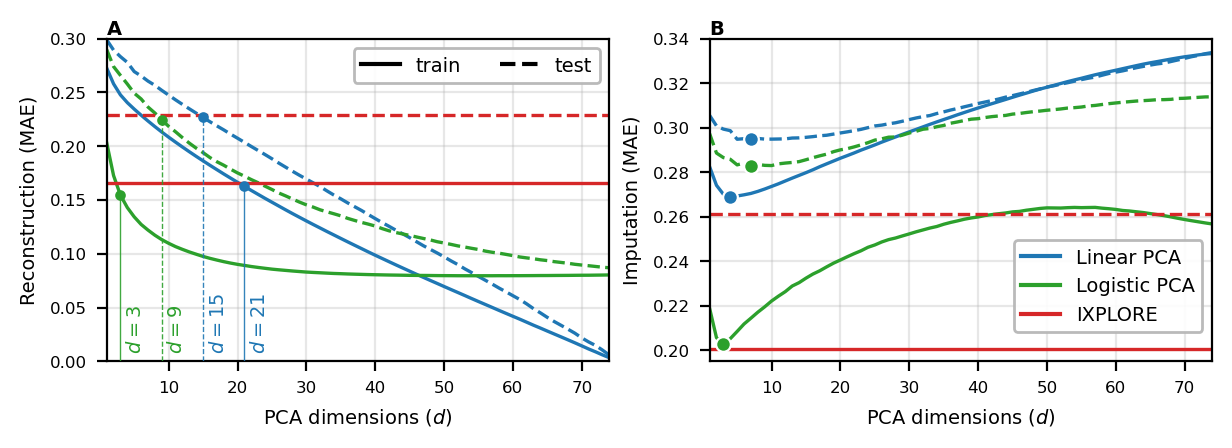

In [7]:
from matplotlib.lines import Line2D

fig, axes = subplots(1, 2, width_frac=1.0, aspect=0.35)

variant_colors = {
    "pca-linear":   "C0",
    "pca-logistic": "C2",
    "ixplore":      "C3",
}
split_styles = {"train": "-", "test": "--"}

panels = [
    (axes[0], f"fit_{SELECTED_METRIC}",    f"Reconstruction ({metric_label})"),
    (axes[1], f"impute_{SELECTED_METRIC}", f"Imputation ({metric_label})"),
]
axes[0].set_ylim(0, 0.3)
axes[1].set_ylim(0.195, 0.34)
# First pass: plot all curves and IXPLORE reference lines so each axes' ylim
# settles before we draw crossover markers (which extend down to the x-axis).
for ax, metric, ylabel in panels:
    for variant in ("pca-linear", "pca-logistic"):
        color = variant_colors[variant]
        sub = pca_avg[pca_avg["model"] == variant]
        for split, ls in split_styles.items():
            ax.plot(sub["k"], sub[f"{split}_{metric}"], color=color, linestyle=ls)

    for split, ls in split_styles.items():
        v = ixplore_ref.get(f"{split}_{metric}")
        if v is None or pd.isna(v):
            continue
        ax.axhline(v, color=variant_colors["ixplore"], linestyle=ls, linewidth=1.2)

    ax.set_xlabel(r"PCA dimensions ($d$)")
    ax.set_ylabel(ylabel)
    ax.set_xlim(1, 74)

# Second pass: crossover markers. Lock ylim before drawing so the vertical
# lines anchored at the axis bottom don't shift the view, and place the k
# labels just inside the bottom of the axes (rotated, in variant color).
for ax, metric, ylabel in panels:
    metric_kind = metric.split("_")[0]
    y_bottom, y_top = ax.get_ylim()
    ax.set_ylim(y_bottom, y_top)

    crossovers_for_panel = []
    for variant in ("pca-linear", "pca-logistic"):
        color = variant_colors[variant]
        sub = pca_avg[pca_avg["model"] == variant]
        for split, ls in split_styles.items():
            col = f"{split}_{metric}"
            k_cross = crossover_k.get(variant, {}).get((split, metric_kind))
            if k_cross is not None:
                y_at_k = float(sub.loc[sub["k"] == k_cross, col].iloc[0])
                ax.plot([k_cross, k_cross], [y_bottom, y_at_k],
                        color=color, linestyle=ls, linewidth=0.5, alpha=0.9, zorder=4)
                ax.scatter([k_cross], [y_at_k], s=8, color=color, zorder=6)
                crossovers_for_panel.append((k_cross, color))
            else:
                ext = extreme_k.get(variant, {}).get((split, metric_kind))
                if ext is not None:
                    k_ext, v_ext = ext
                    ax.scatter([k_ext], [v_ext], s=28, color=color,
                               edgecolors="white", linewidths=0.8, zorder=6)

    for k_cross, color in crossovers_for_panel:
        ax.annotate(
            f"$d={k_cross}$",
            xy=(k_cross, 0), xycoords=("data", "axes fraction"),
            xytext=(2, 3), textcoords="offset points",
            color=color, rotation=90, fontsize=7, ha="left", va="bottom",
            zorder=7,
        )

# Top-left of left panel: train/test linestyle key (2 columns).
split_handles = [
    Line2D([0], [0], color="black", lw=1.5, linestyle=ls, label=split)
    for split, ls in split_styles.items()
]
axes[0].legend(handles=split_handles, loc="upper right", ncol=2, frameon=True, framealpha=0.9)

# Bottom-right of right panel: algorithm color key (1 column).
algo_handles = [
    Line2D([0], [0], color=variant_colors[m], lw=1.5, label=ALGORITHM_LABELS[m])
    for m in ("pca-linear", "pca-logistic", "ixplore")
]
axes[1].legend(handles=algo_handles, loc="lower right", ncol=1, frameon=True, framealpha=0.9,
                bbox_to_anchor=(1.0, 0.06))
fig.text(-0,1, 'A', va='bottom', ha='left', weight='bold', transform=axes[0].transAxes)
fig.text(-0,1, 'B', va='bottom', ha='left', weight='bold', transform=axes[1].transAxes)

FIGURES.mkdir(parents=True, exist_ok=True)
out_path = FIGURES / f"pca_dimensionality_{SELECTED_METRIC}_{DATASET}.pdf"
fig.tight_layout(pad=0.2, rect=[0, 0, 1, 0.96], w_pad=0.7)
fig.savefig(out_path)
print(f"Saved: {out_path}")
plt.show()